In [1]:
from pathlib import Path
import pandas as pd
import sqlite3

In [2]:
cnx = sqlite3.connect('offers.sqlite3')

In [3]:
df_parsed = pd.read_sql_query("SELECT * FROM parsed", cnx)
df_parsed = df_parsed[
    (df_parsed['serie'] != "Other")
    & (df_parsed['generationCPU'] != "Other")
    & (df_parsed['damaged'] == 0)]

target_set = set(df_parsed['listingID'])

df_parsed.head()


,listingID,serie,generationCPU,familyCPU,RAM,storageSize,screenSize,damaged,batteryHealth,year
2,1073822559,Air,M4,Base,16,256,13,0,0,2025
5,1073821889,Pro,M2,Base,16,256,13,0,0,2022
6,1073821855,Pro,M1,Base,8,512,13,0,100,0
7,54365199,Pro,M3,Base,8,512,14,0,88,2023
9,1073820365,Air,M3,Base,16,512,13,0,0,0


In [4]:
df_offers = pd.read_sql_query("SELECT * FROM offers", cnx)

df_offers = df_offers.loc[:, ['listingID', 'price', 'date', 'lastSeen']]
df_offers = df_offers[df_offers['listingID'].isin(target_set)]

df_offers["price"] = (
    df_offers["price"]
    .str.replace(r"\D", "", regex=True)
    .astype(int)
)

df_offers["date"] = pd.to_datetime(df_offers["date"])
df_offers["lastSeen"] = pd.to_datetime(df_offers["lastSeen"])

df_offers.head()

,listingID,price,date,lastSeen
2,1073822559,850,2026-08-13 16:22:11+02:00,2026-08-13 22:51:27.880163+00:00
5,1073821889,590,2026-08-13 12:08:09+02:00,2026-08-17 17:30:30.157570+00:00
6,1073821855,450,2026-08-13 11:58:40+02:00,2026-08-17 17:30:30.157609+00:00
7,54365199,999,2026-08-13 10:19:48+02:00,2026-08-17 17:30:30.157658+00:00
9,1073820365,850,2026-08-12 18:29:02+02:00,2026-08-17 17:30:30.157728+00:00


In [5]:
df_prices = pd.read_sql_query("SELECT * FROM offer_price_history", cnx)

df_prices = df_prices[df_prices['listingID'].isin(target_set)]

df_prices["price"] = (
    df_prices["price"]
    .str.replace(r"\D", "", regex=True)
    .astype(int)
)
df_prices["observedAt"] = pd.to_datetime(df_prices["observedAt"])

df_prices.head()

,listingID,price,observedAt
2,1073822559,850,2026-08-13 22:51:27.880163+00:00
5,1073821889,590,2026-08-13 22:51:27.880307+00:00
6,1073821855,450,2026-08-13 22:51:27.880335+00:00
7,54365199,999,2026-08-13 22:51:27.880369+00:00
9,1073820365,850,2026-08-13 22:51:27.880453+00:00


In [6]:
df_market = df_parsed.merge(df_offers, on='listingID')

df_market.head()

,listingID,serie,generationCPU,familyCPU,RAM,storageSize,screenSize,damaged,batteryHealth,year,price,date,lastSeen
0,1073822559,Air,M4,Base,16,256,13,0,0,2025,850,2026-08-13 16:22:11+02:00,2026-08-13 22:51:27.880163+00:00
1,1073821889,Pro,M2,Base,16,256,13,0,0,2022,590,2026-08-13 12:08:09+02:00,2026-08-17 17:30:30.157570+00:00
2,1073821855,Pro,M1,Base,8,512,13,0,100,0,450,2026-08-13 11:58:40+02:00,2026-08-17 17:30:30.157609+00:00
3,54365199,Pro,M3,Base,8,512,14,0,88,2023,999,2026-08-13 10:19:48+02:00,2026-08-17 17:30:30.157658+00:00
4,1073820365,Air,M3,Base,16,512,13,0,0,0,850,2026-08-12 18:29:02+02:00,2026-08-17 17:30:30.157728+00:00


# Apple Silicon MacBook market study

### What counts as a genuine catch in this market?

This report estimates the *expected asking price* of each listing from its observable specifications, then calls the unusually cheap tail a **catch candidate**. It also asks whether those candidates disappear faster—a useful but imperfect proxy for a sale.

> **Bottom line:** the price model isolates unusual value now; sale velocity is deliberately kept as separate supporting evidence because disappearance can also mean withdrawal and short windows produce wide uncertainty. Treat the result as a shortlist generator, not an automatic purchase decision.

All figures and conclusions below are calculated from `df_market` and `df_prices` when the notebook runs. Plotting requires Matplotlib and Seaborn.

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"ink": "#17324D", "blue": "#2F6BFF", "teal": "#00A6A6", "gold": "#F2B134", "red": "#D1495B", "grey": "#8A94A6"}
GEN_ORDER = [g for g in ["M1", "M2", "M3", "M4", "M5"] if g in set(df_market["generationCPU"])]


def metric_cards(items):
    cards = "".join(
        f"<div class='metric'><div class='metric-value'>{value}</div><div class='metric-label'>{label}</div></div>"
        for label, value in items
    )
    display(HTML(f"<div class='metric-row'>{cards}</div>"))


display(HTML('''
<style>
.metric-row {display:flex; flex-wrap:wrap; gap:12px; margin:12px 0 18px 0}
.metric {min-width:145px; padding:14px 16px; border:1px solid #dfe5ec; border-radius:10px; background:#f8fafc}
.metric-value {font-size:24px; font-weight:700; color:#17324D}
.metric-label {font-size:12px; color:#596579; margin-top:3px}
.callout {padding:12px 15px; border-left:4px solid #2F6BFF; background:#f3f7ff; margin:12px 0}
</style>
'''))

# Analysis copy: normalize equivalent storage labels without changing the source frames.
market = df_market.copy()
market["storageGB"] = pd.to_numeric(market["storageSize"], errors="coerce").replace({500: 512, 1000: 1024, 2000: 2048})
for column in ["RAM", "screenSize", "year", "batteryHealth", "price"]:
    market[column] = pd.to_numeric(market[column], errors="coerce")
market = market.loc[market["price"].gt(0)].copy()
market["listingAgeDays"] = (market["lastSeen"] - market["date"]).dt.total_seconds().div(86400).clip(lower=0)


## 1. Dataset footprint and measurement limits

Before pricing anything, it is worth separating three clocks:

- `date`: when the seller published the offer;
- `observedAt`: when the scraper recorded a price;
- `lastSeen`: the last scan in which the offer was still present.

The publication-to-`lastSeen` duration is **listing age**, not a proven time-to-sale. Offers still visible at the final scan are right-censored. Offers that vanish may have sold, expired, or been withdrawn.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


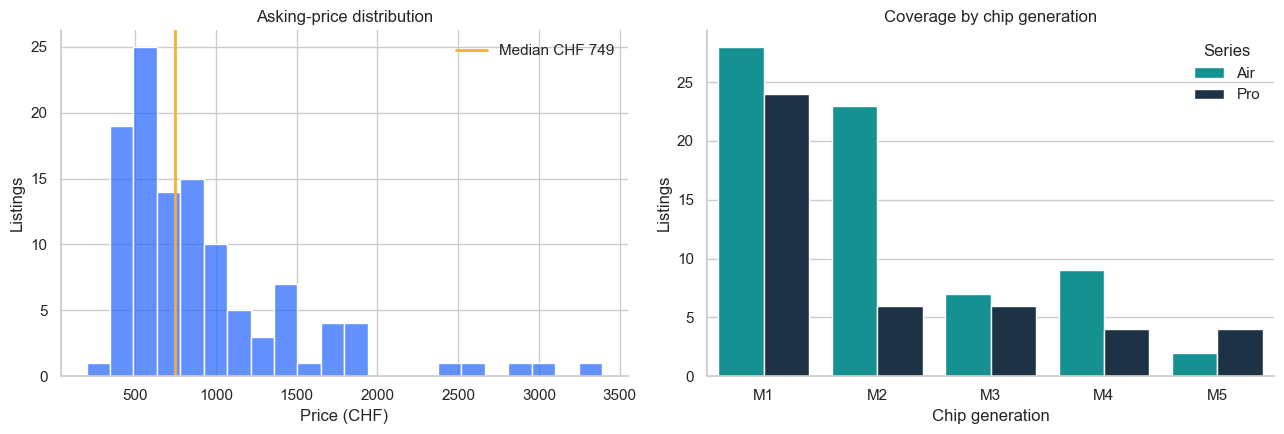

,unknown_rows,unknown_share
RAM,5,4.4%
Storage,6,5.3%
Screen size,1,0.9%
Year,38,33.6%
Battery health,70,61.9%


In [8]:
history_counts = df_prices.groupby("listingID").size()
changed_ids = df_prices.groupby("listingID")["price"].nunique().gt(1)
unknown_specs = market[["RAM", "storageGB", "screenSize", "year", "batteryHealth"]].le(0).mean().mul(100)
window_days = (df_prices["observedAt"].max() - df_prices["observedAt"].min()).total_seconds() / 86400

metric_cards([
    ("Listings", f"{len(market):,}"),
    ("Observed prices", f"{len(df_prices):,}"),
    ("Observation window", f"{window_days:.1f} days"),
    ("Listings with a price change", f"{changed_ids.sum():,}"),
    ("Battery health reported", f"{market['batteryHealth'].gt(0).mean():.1%}"),
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(market["price"], bins=22, color=COLORS["blue"], edgecolor="white", ax=axes[0])
axes[0].axvline(market["price"].median(), color=COLORS["gold"], lw=2, label=f"Median CHF {market['price'].median():,.0f}")
axes[0].set(title="Asking-price distribution", xlabel="Price (CHF)", ylabel="Listings")
axes[0].legend(frameon=False)

sns.countplot(data=market, x="generationCPU", hue="serie", order=GEN_ORDER, palette=[COLORS["teal"], COLORS["ink"]], ax=axes[1])
axes[1].set(title="Coverage by chip generation", xlabel="Chip generation", ylabel="Listings")
axes[1].legend(title="Series", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

quality = pd.DataFrame({
    "unknown_rows": [int(market[c].le(0).sum()) for c in ["RAM", "storageGB", "screenSize", "year", "batteryHealth"]],
    "unknown_share": [market[c].le(0).mean() for c in ["RAM", "storageGB", "screenSize", "year", "batteryHealth"]],
}, index=["RAM", "Storage", "Screen size", "Year", "Battery health"])
display(quality.style.format({"unknown_share": "{:.1%}"}).set_caption("Specification completeness"))

display(HTML(
    f"<div class='callout'><b>Coverage warning.</b> {int((history_counts == 1).sum())} of {len(history_counts)} listings "
    f"have only one recorded price. Price trajectories therefore cannot yet carry much weight.</div>"
))


## 2. Market map: generation and product line do most of the visible work

Raw asking prices rise strongly with newer chip generations, and Pro machines span a much wider range because “Pro” contains both entry-level and high-end Pro/Max chips. The box plot deliberately uses a logarithmic price scale so that unusually low listings remain visible instead of flattening the rest of the market.

These are descriptive prices, not like-for-like premiums: RAM, storage, screen size, year, condition, battery health, and seller quality are mixed together.

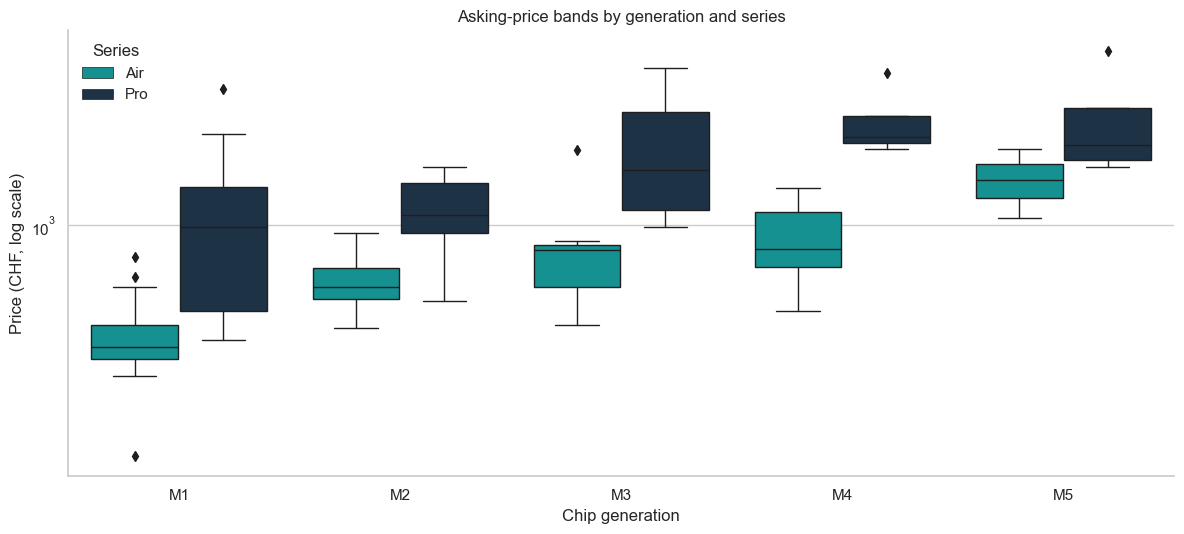

,serie,generationCPU,listings,median_price,q25,q75
0,Air,M1,28,CHF 429,CHF 394,CHF 500
5,Pro,M1,24,CHF 992,CHF 550,"CHF 1,312"
1,Air,M2,23,CHF 650,CHF 600,CHF 745
6,Pro,M2,6,"CHF 1,075",CHF 950,"CHF 1,349"
2,Air,M3,7,CHF 845,CHF 650,CHF 874
7,Pro,M3,6,"CHF 1,475","CHF 1,112","CHF 2,212"
3,Air,M4,9,CHF 849,CHF 749,"CHF 1,100"
8,Pro,M4,4,"CHF 1,850","CHF 1,775","CHF 2,150"
4,Air,M5,2,"CHF 1,375","CHF 1,212","CHF 1,538"
9,Pro,M5,4,"CHF 1,750","CHF 1,574","CHF 2,272"


In [9]:
config_summary = (
    market.groupby(["serie", "generationCPU"], observed=True)
    .agg(listings=("price", "size"), median_price=("price", "median"), q25=("price", lambda x: x.quantile(.25)), q75=("price", lambda x: x.quantile(.75)))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.boxplot(
    data=market, x="generationCPU", y="price", hue="serie", order=GEN_ORDER,
    palette=[COLORS["teal"], COLORS["ink"]], showfliers=True, linewidth=1, ax=ax,
)
ax.set_yscale("log")
ax.set(title="Asking-price bands by generation and series", xlabel="Chip generation", ylabel="Price (CHF, log scale)")
ax.legend(title="Series", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

display(
    config_summary.sort_values(["generationCPU", "serie"])
    .style.format({"median_price": "CHF {:,.0f}", "q25": "CHF {:,.0f}", "q75": "CHF {:,.0f}"})
    .set_caption("Raw market bands (25th percentile, median, 75th percentile)")
)


## 3. A comparable-value model

A catch is not simply the cheapest MacBook. It is a listing priced unusually low **for its specification**.

The model below predicts log asking price from series, chip generation, chip family, screen size, RAM, storage, year, and reported battery health. Zero-valued specifications are treated as *unknown* rather than literal zero. Battery health is centered on 90%; an unknown value receives that neutral reference and no separate missingness premium or penalty. A Huber-style robust fit repeatedly downweights large residuals, preventing the very bargains we want to find from dragging their own benchmark downward.

The central statistic is:

\[
\text{model discount} = 1 - \frac{\text{asking price}}{\text{expected asking price}}
\]

It captures observable hardware value only. Damaged listings are excluded before modeling. Keyboard layout, warranty, cosmetic nuance among otherwise usable devices, locked devices, scams, and accessories remain absent from the data.

In [10]:
def fit_value_model(frame, include_battery=True):
    '''Return listing-level model results using only NumPy/pandas.'''
    m = frame.loc[frame["price"].gt(0)].copy()
    m["storageGB"] = pd.to_numeric(m["storageSize"], errors="coerce").replace({500: 512, 1000: 1024, 2000: 2048})

    blocks = [np.ones((len(m), 1))]
    for column in ["serie", "generationCPU", "familyCPU", "screenSize"]:
        blocks.append(pd.get_dummies(m[column].astype(str), prefix=column, drop_first=True, dtype=float).to_numpy())

    for column in ["RAM", "storageGB", "year"]:
        values = pd.to_numeric(m[column], errors="coerce").astype(float)
        missing = values.isna() | values.le(0)
        observed = values.loc[~missing]
        fallback = 2023 if column == "year" else 1
        filled = values.mask(missing, observed.median() if len(observed) else fallback)
        if column in ["RAM", "storageGB"]:
            filled = np.log2(filled)
        spread = filled.std()
        blocks += [((filled - filled.mean()) / (spread if spread else 1)).to_numpy()[:, None], missing.astype(float).to_numpy()[:, None]]

    battery_used = include_battery and "batteryHealth" in m
    if battery_used:
        battery = pd.to_numeric(m["batteryHealth"], errors="coerce")
        known_battery = battery.between(1, 100)
        # ponytail: missing battery health is common, so 90% is a neutral reference; add a missingness term only with more data.
        battery_centered = battery.where(known_battery, 90).sub(90).div(10)
        blocks.append(battery_centered.to_numpy()[:, None])

    X = np.hstack(blocks)
    y = np.log(m["price"].to_numpy(dtype=float))
    weights = np.ones(len(y))

    for _ in range(40):
        root_w = np.sqrt(weights)
        beta = np.linalg.lstsq(X * root_w[:, None], y * root_w, rcond=None)[0]
        residual = y - X @ beta
        center = np.median(residual)
        scale = 1.4826 * np.median(np.abs(residual - center)) + 1e-9
        scaled = np.abs(residual - center) / (1.345 * scale)
        new_weights = np.divide(1, scaled, out=np.ones_like(scaled), where=scaled > 1)
        if np.max(np.abs(new_weights - weights)) < 1e-6:
            break
        weights = new_weights

    m["expectedPrice"] = np.exp(X @ beta)
    m["logResidual"] = np.log(m["price"]) - np.log(m["expectedPrice"])
    m["modelDiscountPct"] = 100 * (1 - m["price"] / m["expectedPrice"])
    m["absolutePctError"] = 100 * np.abs(m["price"] - m["expectedPrice"]) / m["price"]

    # Stable order makes the rarity bands exact even if residuals tie.
    ordered = m.sort_values(["logResidual", "listingID"]).index
    m["rankPosition"] = pd.Series(np.arange(1, len(m) + 1), index=ordered)
    m["valuePercentile"] = 100 * (len(m) - m["rankPosition"] + 1) / len(m)
    n_top1, n_top5 = max(1, math.ceil(.01 * len(m))), max(1, math.ceil(.05 * len(m)))
    m["rarityBand"] = np.select(
        [m["rankPosition"].le(n_top1), m["rankPosition"].le(n_top5)],
        ["Top 1% candidate", "Top 5% candidate"], default="Market range",
    )

    weighted_mean = np.average(y, weights=weights)
    r2 = 1 - np.sum(weights * residual ** 2) / np.sum(weights * (y - weighted_mean) ** 2)
    diagnostics = {"robust_r2": r2, "median_absolute_pct_error": m["absolutePctError"].median(), "residual_scale": scale}
    if battery_used:
        diagnostics["battery_premium_per_10pp"] = 100 * (np.exp(beta[-1]) - 1)
    return m, diagnostics


value_model, model_diagnostics = fit_value_model(market)
no_battery_model, _ = fit_value_model(market, include_battery=False)
battery_impact = value_model[["listingID", "expectedPrice", "rankPosition"]].merge(
    no_battery_model[["listingID", "expectedPrice", "rankPosition"]], on="listingID", suffixes=("_with", "_without")
)
battery_impact["expectedShiftPct"] = 100 * (battery_impact["expectedPrice_with"] / battery_impact["expectedPrice_without"] - 1)
top_n = math.ceil(.05 * len(value_model))
top_with = set(value_model.nsmallest(top_n, "rankPosition")["listingID"])
top_without = set(no_battery_model.nsmallest(top_n, "rankPosition")["listingID"])

metric_cards([
    ("Robust R² (log price)", f"{model_diagnostics['robust_r2']:.2f}"),
    ("Median absolute error", f"{model_diagnostics['median_absolute_pct_error']:.1f}%"),
    ("Battery effect / +10 points", f"{model_diagnostics['battery_premium_per_10pp']:+.1f}%"),
    ("Median expected-price shift", f"{battery_impact['expectedShiftPct'].abs().median():.1f}%"),
    ("Top 1% candidates", f"{(value_model['rarityBand'] == 'Top 1% candidate').sum()}"),
    ("Top 5% retained", f"{len(top_with & top_without)}/{top_n}"),
])

display(HTML(
    f"<div class='callout'><b>Battery health is a small adjustment.</b> It is reported for "
    f"{market['batteryHealth'].gt(0).mean():.1%} of usable listings. Adding it changes the median expected price by "
    f"{battery_impact['expectedShiftPct'].abs().median():.1f}% and retains {len(top_with & top_without)} of {top_n} top-5% candidates.</div>"
))


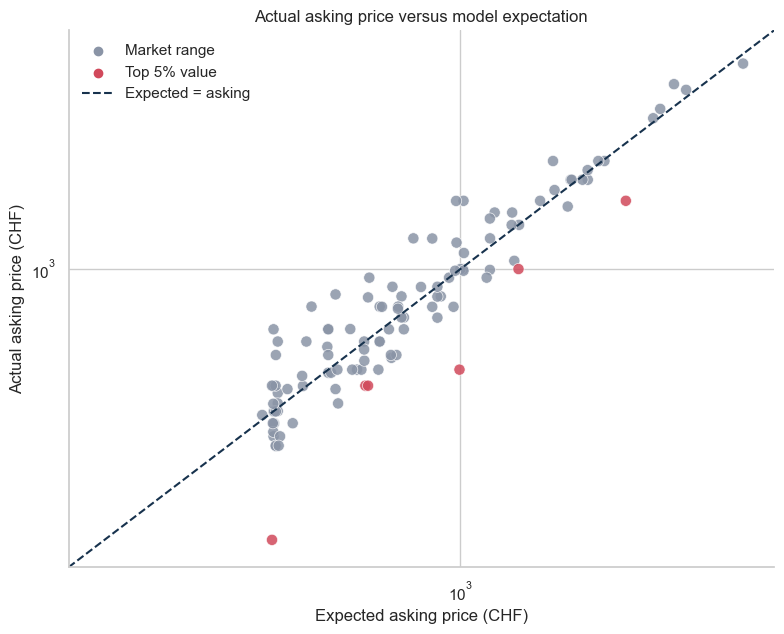

,rankPosition,listingID,model,RAM,storageGB,screenSize,batteryHealth,year,price,expectedPrice,modelDiscountPct,rarityBand
112,1,54763724,Air M1 Base,8,256,13,90,2021,CHF 200,CHF 427,53.1%,Top 1% candidate
29,2,1073778294,Pro M1 Pro,16,1024,14,84,0,CHF 550,CHF 996,44.8%,Top 1% candidate
104,3,1073831341,Pro M2 Max,32,1024,16,92,2023,"CHF 1,500","CHF 2,113",29.0%,Top 5% candidate
84,4,54694463,Air M3 Base,8,256,13,0,2024,CHF 500,CHF 659,24.1%,Top 5% candidate
77,5,54709834,Pro M1 Base,16,512,13,90,2020,CHF 500,CHF 651,23.1%,Top 5% candidate
103,6,54279675,Pro M1 Pro,32,1024,16,0,2021,"CHF 1,000","CHF 1,300",23.1%,Top 5% candidate


In [11]:
plot_model = value_model.copy()
plot_model["plotBand"] = np.where(plot_model["rankPosition"].le(math.ceil(.05 * len(plot_model))), "Top 5% value", "Market range")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.scatterplot(
    data=plot_model, x="expectedPrice", y="price", hue="plotBand",
    hue_order=["Market range", "Top 5% value"], palette=[COLORS["grey"], COLORS["red"]],
    s=65, alpha=.85, edgecolor="white", linewidth=.5, ax=ax,
)
limits = [max(40, min(plot_model["expectedPrice"].min(), plot_model["price"].min()) * .85), max(plot_model["expectedPrice"].max(), plot_model["price"].max()) * 1.15]
ax.plot(limits, limits, ls="--", lw=1.5, color=COLORS["ink"], label="Expected = asking")
ax.set(xscale="log", yscale="log", xlim=limits, ylim=limits, title="Actual asking price versus model expectation", xlabel="Expected asking price (CHF)", ylabel="Actual asking price (CHF)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

top_preview = value_model.nsmallest(math.ceil(.05 * len(value_model)), "rankPosition").copy()
top_preview["model"] = top_preview.apply(lambda r: f"{r['serie']} {r['generationCPU']} {r['familyCPU']}", axis=1)
display(
    top_preview[["rankPosition", "listingID", "model", "RAM", "storageGB", "screenSize", "batteryHealth", "year", "price", "expectedPrice", "modelDiscountPct", "rarityBand"]]
    .style.format({"price": "CHF {:,.0f}", "expectedPrice": "CHF {:,.0f}", "modelDiscountPct": "{:.1f}%"})
    .background_gradient(subset=["modelDiscountPct"], cmap="YlGn")
    .set_caption("Model-defined rare-value tail; due diligence is added in the final detector")
)


## 4. Does unusual value disappear faster?

The price-history timestamps are grouped into scan sessions whenever observations are separated by more than six hours. For a clean comparison, only listings present in the first session are considered “at risk.” A listing last seen before the midpoint between the two most recent sessions is marked **disappeared**. This avoids falsely counting listings first discovered later and continues to work as new scan sessions accumulate.

Because the outcome is disappearance rather than a confirmed sale, it is a secondary validation signal—not part of the core value score.

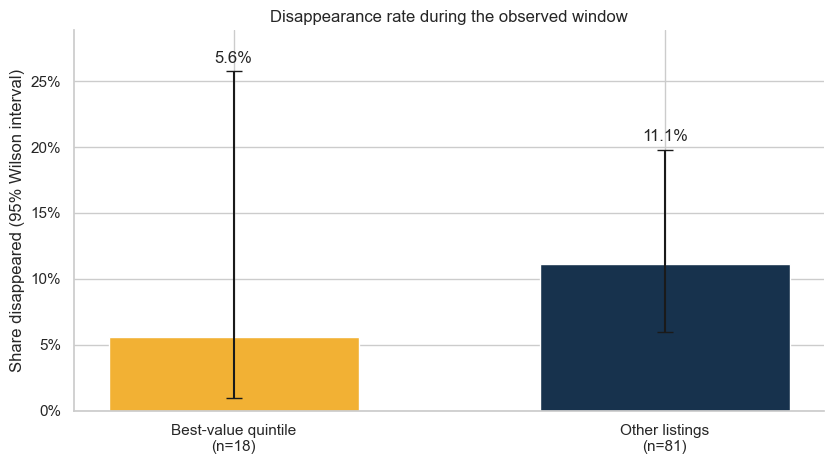

In [12]:
observations = df_prices.sort_values("observedAt").copy()
observations["scanSession"] = observations["observedAt"].diff().gt(pd.Timedelta("6h")).cumsum()
sessions = observations.groupby("scanSession")["observedAt"].agg(["min", "max", "size"])

timed = value_model.copy()
timed["listingAgeDays"] = (timed["lastSeen"] - timed["date"]).dt.total_seconds().div(86400).clip(lower=0)

if len(sessions) >= 2:
    first_session, latest_session = sessions.index.min(), sessions.index.max()
    cohort_ids = set(observations.loc[observations["scanSession"].eq(first_session), "listingID"])
    first_scan = sessions.loc[first_session, "min"]
    latest_scan = sessions.loc[latest_session, "min"]
    previous_scan = sessions.iloc[-2]["min"]
    disappearance_cutoff = previous_scan + (latest_scan - previous_scan) / 2
    timed["initialCohort"] = timed["listingID"].isin(cohort_ids)
    timed["disappeared"] = timed["initialCohort"] & timed["lastSeen"].lt(disappearance_cutoff)
else:
    first_scan = latest_scan = observations["observedAt"].min()
    timed["initialCohort"] = True
    timed["disappeared"] = False

cohort = timed.loc[timed["initialCohort"]].copy()
cohort["valueGroup"] = np.where(cohort["valuePercentile"].ge(80), "Best-value quintile", "Other listings")

def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return (np.nan, np.nan)
    p = successes / total
    center = (p + z*z/(2*total)) / (1 + z*z/total)
    half = z * np.sqrt((p*(1-p) + z*z/(4*total))/total) / (1 + z*z/total)
    return center - half, center + half

exit_summary = (
    cohort.groupby("valueGroup", observed=True)["disappeared"]
    .agg([("listings", "size"), ("disappeared", "sum"), ("exit_rate", "mean")])
    .reindex(["Best-value quintile", "Other listings"])
)
intervals = [wilson_interval(int(r.disappeared), int(r.listings)) for r in exit_summary.itertuples()]
exit_summary["ci_low"], exit_summary["ci_high"] = zip(*intervals)

metric_cards([
    ("Effective scan sessions", f"{len(sessions)}"),
    ("Initial at-risk cohort", f"{len(cohort)}"),
    ("Disappeared listings", f"{int(cohort['disappeared'].sum())}"),
    ("Window between scans", f"{(latest_scan-first_scan).total_seconds()/86400:.1f} days"),
])

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(exit_summary))
rates = exit_summary["exit_rate"].to_numpy()
errors = np.vstack([rates - exit_summary["ci_low"].to_numpy(), exit_summary["ci_high"].to_numpy() - rates])
bars = ax.bar(x, rates, color=[COLORS["gold"], COLORS["ink"]], width=.58, yerr=errors, capsize=6)
ax.set_xticks(x, [f"{label}\n(n={int(exit_summary.loc[label, 'listings'])})" for label in exit_summary.index])
ax.set_ylim(0, max(.25, float(exit_summary["ci_high"].max()) * 1.12))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set(title="Disappearance rate during the observed window", xlabel="", ylabel="Share disappeared (95% Wilson interval)")
ax.bar_label(bars, labels=[f"{r:.1%}" for r in rates], padding=4)
sns.despine()
plt.tight_layout()
plt.show()

best_rate = exit_summary.loc["Best-value quintile", "exit_rate"]
other_rate = exit_summary.loc["Other listings", "exit_rate"]
direction = "higher" if best_rate > other_rate else "lower"
display(HTML(
    f"<div class='callout'><b>No reliable velocity confirmation yet.</b> The best-value quintile disappeared at "
    f"{best_rate:.1%} versus {other_rate:.1%} for other listings ({direction}, not a meaningful separation with only "
    f"{int(cohort['disappeared'].sum())} events). The wide, overlapping intervals are the important result.</div>"
))


## 5. Price changes: currently a footnote

When only a few prices have changed, discount cadence, seller responsiveness, and price-drop survival cannot be estimated reliably. The table becomes more informative automatically as the observation window grows.

In [13]:
price_paths = (
    df_prices.sort_values("observedAt")
    .groupby("listingID")
    .agg(observations=("price", "size"), distinct_prices=("price", "nunique"), first_price=("price", "first"), last_price=("price", "last"), first_observed=("observedAt", "first"), last_observed=("observedAt", "last"))
)
price_paths["change_chf"] = price_paths["last_price"] - price_paths["first_price"]
price_paths["change_pct"] = 100 * price_paths["change_chf"] / price_paths["first_price"]
price_changes = price_paths.loc[price_paths["distinct_prices"].gt(1)].sort_values("change_pct")

if len(price_changes):
    display(price_changes.style.format({"first_price": "CHF {:,.0f}", "last_price": "CHF {:,.0f}", "change_chf": "CHF {:+,.0f}", "change_pct": "{:+.1f}%"}).set_caption("Observed price changes"))
else:
    display(HTML("<div class='callout'>No listing changed price during the observation window.</div>"))


,observations,distinct_prices,first_price,last_price,first_observed,last_observed,change_chf,change_pct
listingID,,,,,,,,
1073818357,2,2,"CHF 2,000","CHF 1,700",2026-08-13 22:51:27.880604+00:00,2026-08-17 17:00:36.015353+00:00,CHF -300,-15.0%
54777639,2,2,CHF 650,CHF 600,2026-08-13 22:51:40.124408+00:00,2026-08-17 17:00:46.496703+00:00,CHF -50,-7.7%
1073819620,2,2,CHF 829,CHF 799,2026-08-13 22:51:27.880484+00:00,2026-08-17 17:00:33.246084+00:00,CHF -30,-3.6%


## 6. Catch detector: an operational shortlist

The detector implements the study as a reproducible ranking:

1. **Filter** damaged listings, normalize storage aliases, and treat zero specifications—including battery health—as unknown.
2. **Estimate expected asking price** with the robust log-price model; reported battery health enters as a small continuous adjustment around a neutral 90% reference.
3. **Rank model residuals** from most underpriced to most overpriced.
4. **Assign rarity exactly by rank:** the first `ceil(1% × N)` are “Top 1% candidates”; through `ceil(5% × N)` are “Top 5% candidates.”
5. **Attach confidence:** complete specifications plus at least five same-series/generation/chip-family peers is High; slightly weaker coverage is Medium; otherwise Low.
6. **Attach—not blend—velocity:** fast disappearance is supporting evidence only. It does not improve the price rank until a longer window demonstrates that it predicts sales.
7. **Flag due diligence:** extreme absolute price, missing specifications, and sparse peer groups are reasons to inspect the ad, not reasons to silently discard a possible bargain.

This separation is deliberate: the value score answers “cheap for the stated hardware,” while the flags answer “how much should I trust the stated hardware?”

In [14]:
def detect_catches(df_market, df_prices, top_share=.05):
    '''Rank unusually cheap Apple Silicon listings and attach evidence-quality flags.'''
    usable = df_market.loc[df_market["damaged"].eq(0)] if "damaged" in df_market else df_market
    ranked, diagnostics = fit_value_model(usable.copy())
    ranked["storageGB"] = pd.to_numeric(ranked["storageSize"], errors="coerce").replace({500: 512, 1000: 1024, 2000: 2048})
    ranked["specCompleteness"] = ranked[["RAM", "storageGB", "screenSize", "year"]].gt(0).mean(axis=1)
    ranked["peerCount"] = ranked.groupby(["serie", "generationCPU", "familyCPU"])["listingID"].transform("size")
    ranked["confidence"] = np.select(
        [(ranked["specCompleteness"].eq(1) & ranked["peerCount"].ge(5)),
         (ranked["specCompleteness"].ge(.75) & ranked["peerCount"].ge(3))],
        ["High", "Medium"], default="Low",
    )

    ranked["listingAgeDays"] = (ranked["lastSeen"] - ranked["date"]).dt.total_seconds().div(86400).clip(lower=0)
    observations = df_prices.sort_values("observedAt").copy()
    observations["scanSession"] = observations["observedAt"].diff().gt(pd.Timedelta("6h")).cumsum()
    sessions = observations.groupby("scanSession")["observedAt"].agg(["min", "max", "size"])
    ranked["velocitySignal"] = "Not testable"
    if len(sessions) >= 2:
        first_id, latest_id = sessions.index.min(), sessions.index.max()
        cohort_ids = set(observations.loc[observations["scanSession"].eq(first_id), "listingID"])
        previous_scan = sessions.iloc[-2]["min"]
        cutoff = previous_scan + (sessions.loc[latest_id, "min"] - previous_scan) / 2
        disappeared = ranked["listingID"].isin(cohort_ids) & ranked["lastSeen"].lt(cutoff)
        fast_cutoff = ranked.loc[disappeared, "listingAgeDays"].quantile(.25) if disappeared.any() else -1
        ranked.loc[ranked["listingID"].isin(cohort_ids), "velocitySignal"] = "Still observed"
        ranked.loc[disappeared, "velocitySignal"] = "Disappeared"
        ranked.loc[disappeared & ranked["listingAgeDays"].le(fast_cutoff), "velocitySignal"] = "Fast disappearance"

    absolute_floor = ranked["price"].quantile(.01)
    def flags(row):
        notes = []
        if row["price"] <= absolute_floor:
            notes.append("extreme price—verify device/ad")
        if row["specCompleteness"] < .75:
            notes.append("missing key specs")
        if row["peerCount"] < 3:
            notes.append("sparse comparison group")
        return "; ".join(notes) or "standard checks"

    ranked["dueDiligence"] = ranked.apply(flags, axis=1)
    shortlist_n = max(1, math.ceil(top_share * len(ranked)))
    shortlist = ranked.nsmallest(shortlist_n, "rankPosition").copy()
    shortlist["model"] = shortlist.apply(lambda r: f"{r['serie']} {r['generationCPU']} {r['familyCPU']}", axis=1)
    return shortlist, ranked, diagnostics


catches, catch_universe, catch_diagnostics = detect_catches(df_market, df_prices, top_share=.05)
assert len(catches) == math.ceil(.05 * len(catch_universe))
assert catches["rankPosition"].is_monotonic_increasing and catches["rankPosition"].iloc[0] == 1
assert catch_universe["damaged"].eq(0).all() and catch_universe["batteryHealth"].between(0, 100).all()
columns = ["rankPosition", "rarityBand", "listingID", "model", "RAM", "storageGB", "screenSize", "batteryHealth", "year", "price", "expectedPrice", "modelDiscountPct", "confidence", "velocitySignal", "dueDiligence"]
display(
    catches[columns]
    .style.format({"price": "CHF {:,.0f}", "expectedPrice": "CHF {:,.0f}", "modelDiscountPct": "{:.1f}%"})
    .background_gradient(subset=["modelDiscountPct"], cmap="YlGn")
    .set_caption(f"Current top {len(catches)} catch candidates (top 5% of {len(catch_universe)} listings)")
)

display(HTML(
    "<div class='callout'><b>Buying rule:</b> investigate High/Medium-confidence candidates first; require serial-number, "
    "activation-lock, battery-cycle, charger, keyboard-layout, condition, and in-person functional checks before treating a model discount as real.</div>"
))


,rankPosition,rarityBand,listingID,model,RAM,storageGB,screenSize,batteryHealth,year,price,expectedPrice,modelDiscountPct,confidence,velocitySignal,dueDiligence
112,1,Top 1% candidate,54763724,Air M1 Base,8,256,13,90,2021,CHF 200,CHF 427,53.1%,High,Still observed,extreme price—verify device/ad
29,2,Top 1% candidate,1073778294,Pro M1 Pro,16,1024,14,84,0,CHF 550,CHF 996,44.8%,Medium,Still observed,standard checks
104,3,Top 5% candidate,1073831341,Pro M2 Max,32,1024,16,92,2023,"CHF 1,500","CHF 2,113",29.0%,Low,Not testable,sparse comparison group
84,4,Top 5% candidate,54694463,Air M3 Base,8,256,13,0,2024,CHF 500,CHF 659,24.1%,High,Disappeared,standard checks
77,5,Top 5% candidate,54709834,Pro M1 Base,16,512,13,90,2020,CHF 500,CHF 651,23.1%,High,Still observed,standard checks
103,6,Top 5% candidate,54279675,Pro M1 Pro,32,1024,16,0,2021,"CHF 1,000","CHF 1,300",23.1%,High,Not testable,standard checks


### Decision and next-data milestone

This first pass is already useful for **prioritization**: it converts heterogeneous machines into a specification-adjusted top-1%/top-5% queue, exposes why a candidate is risky, and avoids pretending that a disappeared ad is definitely sold.

It is **not yet sufficient to calibrate probability of sale**. The next meaningful milestone is roughly 4–8 weeks of regular scans with enough disappearances in each value band. At that point, validate the residual score out of time, estimate survival from first observation (not publication date), distinguish relistings where possible, and only then consider adding velocity to the ranking.